#Project 7: Understanding Loss Functions in Neural Networks

### Prakruthi BR
### Reg no: 2411021240038
### Subject: Deep Learning


## Objective

The objective of this assignment is to understand how neural networks measure prediction errors using loss functions.

In this assignment, we will:

1. Define actual class labels and predicted outputs for a simple classification problem.
2. Calculate Mean Squared Error (MSE).
3. Calculate Cross-Entropy Loss.
4. Compare the results of both loss functions.
5. Understand when each loss function can be used.

A loss function measures how different the model's predictions are from the actual values.


## Introduction

Neural networks make predictions, and a loss function is used to measure how different those predictions are from the actual values.

In this experiment, we use actual class labels and predicted outputs from a simple classification problem.

We calculate two basic loss functions:

1. Mean Squared Error (MSE)
2. Cross-Entropy Loss

The calculated losses are then compared and their applications are explained.

## 1. Introduction to Loss Functions

A loss function is used to measure the error between the actual output and the predicted output of a machine learning model.

If the prediction is close to the actual value, the loss is generally small.

If the prediction is far from the actual value, the loss is generally large.

During model training, the model tries to minimize the loss.

In this assignment, we compare two loss functions:

- Mean Squared Error (MSE)
- Cross-Entropy Loss

## 2. Simple Classification Problem

We consider a binary classification problem.

There are two possible classes:

- 1 → Positive class
- 0 → Negative class

We have five samples.

The actual class labels are:

[1, 0, 1, 1, 0]

The model also produces a probability for the positive class for each sample.

These probabilities are:

[0.9, 0.2, 0.8, 0.7, 0.1]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Define Actual Class Labels

The actual labels represent the correct answers for each sample.

For our five samples:

- Sample 1 → 1
- Sample 2 → 0
- Sample 3 → 1
- Sample 4 → 1
- Sample 5 → 0

Therefore, the actual labels are:

[1, 0, 1, 1, 0]


In [ ]:
# Actual class labels
actual_labels = np.array([1, 0, 1, 1, 0])

print("Actual class labels:", actual_labels)

Actual class labels: [1 0 1 1 0]


## 4. Define Predicted Outputs

The model produces predicted probabilities for the positive class.

A probability closer to 1 means the model is more confident that the sample belongs to the positive class.

A probability closer to 0 means the model is more confident that the sample belongs to the negative class.

Our predicted probabilities are:

[0.9, 0.2, 0.8, 0.7, 0.1]

In [ ]:
# Predicted probabilities for the positive class
predicted_outputs = np.array([0.9, 0.2, 0.8, 0.7, 0.1])

print("Predicted outputs:", predicted_outputs)

Predicted outputs: [0.9 0.2 0.8 0.7 0.1]


## 5. Difference Between Actual and Predicted Values

The difference between the actual and predicted values is calculated using:

Difference = Actual - Predicted

This helps us understand how far each prediction is from the actual value.

In [ ]:
difference = actual_labels - predicted_outputs

print("Actual Values:    ", actual_labels)
print("Predicted Values: ", predicted_outputs)
print("Difference:       ", difference)


Actual Values:     [1 0 1 1 0]
Predicted Values:  [0.9 0.2 0.8 0.7 0.1]
Difference:        [ 0.1 -0.2  0.2  0.3 -0.1]


## 5. Mean Squared Error (MSE)

Mean Squared Error measures the average squared difference between the actual values and predicted values.

The formula is:

MSE = (1/n) × Σ(y - ŷ)²

Where:

- y = actual value
- ŷ = predicted value
- n = number of samples

MSE gives more importance to larger errors because the errors are squared.

MSE is mainly used for regression problems, where the target values are continuous.

In [ ]:
# Calculate Mean Squared Error
mse = np.mean((actual_labels - predicted_outputs) ** 2)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.038


## 6. Understanding the MSE Calculation

The squared errors for the five samples are:

Sample 1:
(1 - 0.9)² = 0.01

Sample 2:
(0 - 0.2)² = 0.04

Sample 3:
(1 - 0.8)² = 0.04

Sample 4:
(1 - 0.7)² = 0.09

Sample 5:
(0 - 0.1)² = 0.01

Therefore:

MSE = (0.01 + 0.04 + 0.04 + 0.09 + 0.01) / 5

MSE = 0.038

A lower MSE indicates that the predicted values are closer to the actual values for this calculation.

## 7. Cross-Entropy Loss

Cross-Entropy Loss is commonly used for classification problems.

For binary classification, Binary Cross-Entropy can be calculated using:

BCE = -1/n × Σ [y log(p) + (1-y) log(1-p)]

Where:

- y = actual class label
- p = predicted probability
- n = number of samples

Cross-Entropy focuses on the probability assigned to the correct class.

If the model gives a high probability to the correct class, the loss is small.

If the model gives a low probability to the correct class, the loss becomes larger.

## 8. Why Do We Use np.clip()?

The logarithm of 0 is undefined.

Since Cross-Entropy uses logarithms, predicted probabilities should not be exactly 0 or 1 when calculating the formula manually.

Therefore, we use np.clip() to keep the predicted probabilities within a very small safe range.

This prevents numerical problems such as log(0).

In [ ]:
# Prevent log(0) by keeping probabilities within a safe range
epsilon = 1e-15

clipped_predictions = np.clip(
    predicted_outputs,
    epsilon,
    1 - epsilon
)

print("Clipped predictions:", clipped_predictions)

Clipped predictions: [0.9 0.2 0.8 0.7 0.1]


In [ ]:
# Calculate Binary Cross-Entropy Loss
cross_entropy = -np.mean(
    actual_labels * np.log(clipped_predictions)
    + (1 - actual_labels) * np.log(1 - clipped_predictions)
)

print("Cross-Entropy Loss:", cross_entropy)

Cross-Entropy Loss: 0.20273661557656092


## 9. Understanding the Cross-Entropy Result

The calculated Cross-Entropy Loss is approximately:

0.203

The model gives relatively high probabilities to the correct classes in this example.

For example:

- Actual = 1, Prediction = 0.9
- Actual = 0, Prediction = 0.2
- Actual = 1, Prediction = 0.8
- Actual = 1, Prediction = 0.7
- Actual = 0, Prediction = 0.1

Because the predictions are reasonably close to the correct classes, the Cross-Entropy Loss is relatively small for this example.

## 10. Compare MSE and Cross-Entropy Loss

We calculated two different loss values:

- MSE = 0.038
- Cross-Entropy Loss ≈ 0.203

These values should not be directly compared by simply saying that one is better because its number is smaller.

The reason is that MSE and Cross-Entropy use different mathematical formulas and have different scales.

Instead, we should compare how each loss function measures prediction error and when each one is normally used.

In [ ]:
# Store the loss values
loss_names = ["MSE", "Cross-Entropy"]
loss_values = [mse, cross_entropy]

print("Loss Comparison")
print("-------------------------")
print("MSE:", mse)
print("Cross-Entropy:", cross_entropy)

Loss Comparison
-------------------------
MSE: 0.038
Cross-Entropy: 0.20273661557656092


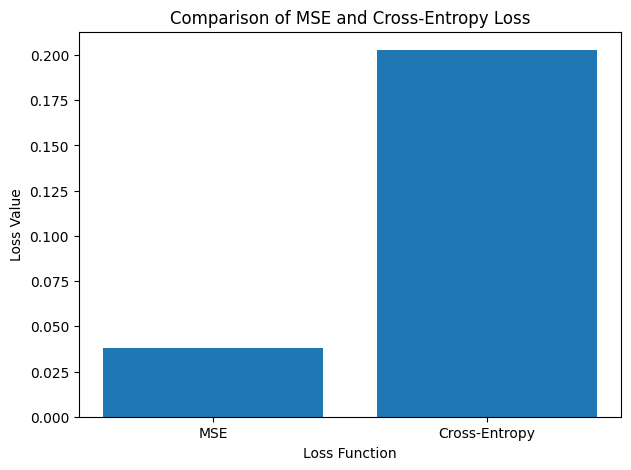

In [ ]:
# Plot the loss values
plt.figure(figsize=(7, 5))

plt.bar(loss_names, loss_values)

plt.title("Comparison of MSE and Cross-Entropy Loss")
plt.xlabel("Loss Function")
plt.ylabel("Loss Value")

plt.show()

## 11. When Can Each Loss Function Be Used?

### Mean Squared Error (MSE)

MSE is mainly used for regression problems.

Examples:

- House price prediction
- Sales prediction
- Temperature prediction
- Stock or numerical value prediction

MSE can also be applied to classification in some situations when class labels are represented numerically, but it is not normally the standard choice for classification.

### Cross-Entropy Loss

Cross-Entropy Loss is commonly used for classification problems.

Examples:

- Binary classification
- Multi-class classification
- Image classification
- Text classification
- Spam detection

For our binary classification example, Binary Cross-Entropy is an appropriate loss function.

## 12. Important Difference

| Feature | MSE | Cross-Entropy |
|---|---|---|
| Full Form | Mean Squared Error | Cross-Entropy Loss |
| Main Use | Regression | Classification |
| Measures | Squared prediction error | Probability assigned to correct class |
| Classification Use | Possible with one-hot encoding | Common choice |
| Input | Continuous targets and predictions | Class labels and logits |
| Penalty | Squared difference | Logarithmic penalty |

## 13. Observation

The calculated losses are:

- Mean Squared Error = 0.038
- Cross-Entropy Loss ≈ 0.203

Both loss functions measure prediction error, but they do so differently.

MSE measures the squared difference between the actual values and predicted probabilities.

Cross-Entropy measures how much probability the model assigns to the correct class.

The numerical values of the two losses should not be directly compared because they are calculated using different formulas and scales.

## 14. Final Result

In this assignment, we used actual class labels and predicted outputs from a simple binary classification problem.

The Mean Squared Error was calculated as:

MSE = 0.038

The Cross-Entropy Loss was calculated as:

Cross-Entropy Loss ≈ 0.203

MSE measures the squared difference between actual and predicted values and is mainly used for regression.

Cross-Entropy Loss measures the probability assigned to the correct class and is commonly used for classification.

Therefore, for a binary classification problem such as the one used in this assignment, Binary Cross-Entropy is the commonly used loss function.

In [ ]:
# Final results
print("FINAL RESULTS")
print("==============")
print(f"Mean Squared Error       : {mse:.3f}")
print(f"Cross-Entropy Loss       : {cross_entropy:.3f}")

FINAL RESULTS
Mean Squared Error       : 0.038
Cross-Entropy Loss       : 0.203


# Conclusion

In this assignment, we studied how loss functions measure prediction errors in a classification problem.

We calculated:

- Mean Squared Error (MSE) = 0.038
- Cross-Entropy Loss ≈ 0.203

MSE calculates the average squared difference between actual and predicted values.

Cross-Entropy Loss evaluates the probability assigned to the correct class and is commonly used for classification problems.

We also observed that the numerical values of different loss functions should not be directly compared because they are based on different formulas and scales.

Overall, loss functions are important because they help neural networks measure prediction errors and guide the model during training.